--- OUTPUT CONFIGURATION ---
Figures will be saved to: /home/basyirin/Research/PIRL_Adaptive_Control/docs/figures

--- PHASE 1: DATA HARVESTING ---
Harvesting...
Symmetry Check:
Pos Samples (>0.05): 4829
Neg Samples (<-0.05): 4870
PASSED: Data symmetry ratio 0.99

--- PHASE 2: TRAINING PIRL NETWORK ---
Epoch 0: Loss 0.05004
Epoch 10: Loss 0.02651
Epoch 20: Loss 0.02626
Epoch 30: Loss 0.02630
Epoch 40: Loss 0.02612
Model Saved.
Saved Friction Fit plot to: /home/basyirin/Research/PIRL_Adaptive_Control/docs/figures/week6_friction_fit.png


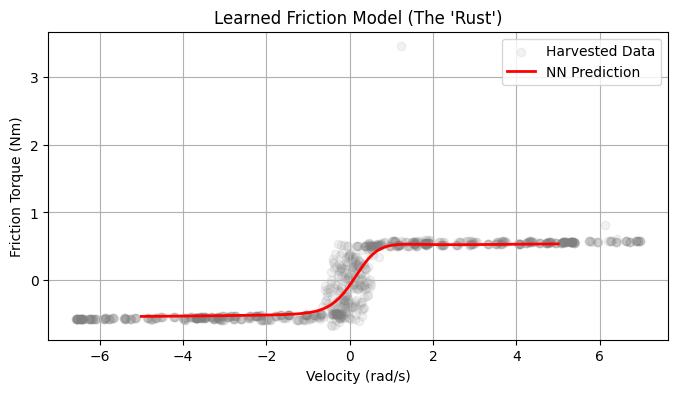


--- PHASE 3: EVALUATION ---
[HybridPIRLController] Model loaded from pirl_model.pth
FINAL RESULT:
Hybrid RMSE: 0.00357 rad
Target RMSE: < 0.005 rad
SUCCESS: Week 6 Gate Passed.
Saved Hybrid Tracking plot to: /home/basyirin/Research/PIRL_Adaptive_Control/docs/figures/week6_hybrid_tracking.png


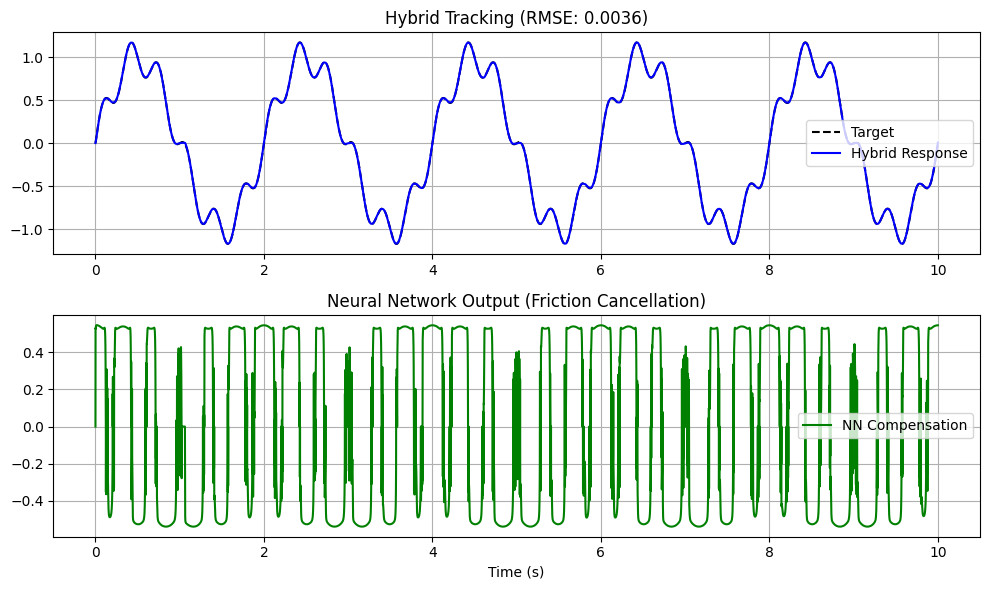

In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Add root to path
sys.path.append(os.path.abspath('..'))

from sim.sim_env import SimpleArmEnv
from sim.baseline_env import PIDController
from sim.pirl_network import PIRLNetwork
from sim.hybrid_controller import HybridPIRLController

# --- CONFIGURATION ---
MODEL_PATH = "pirl_model.pth"
TARGET_RMSE = 0.005 # rad
INERTIA = 0.002
DT = 0.001

# --- OUTPUT SETUP ---
# Standardize output path for documentation
FIGURES_DIR = os.path.expanduser("~/Research/PIRL_Adaptive_Control/docs/figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"--- OUTPUT CONFIGURATION ---")
print(f"Figures will be saved to: {FIGURES_DIR}")

# --- STEP 1: SYMMETRIC HARVESTING ---
print("\n--- PHASE 1: DATA HARVESTING ---")
# We use a Composite Signal (Chirp + Sine) to ensure we hit high/low velocities
# AND symmetric positive/negative directions.

env = SimpleArmEnv()
pid = PIDController(kp=15.0, ki=0.0, kd=0.5) # Tuned baseline

# Generate Reference Trajectory (Composite Sine)
T = 10.0
t = np.linspace(0, T, int(T/DT))
# Signal: Low freq large amplitude + High freq small amplitude
q_targets = 1.0 * np.sin(2 * np.pi * 0.5 * t) + 0.2 * np.sin(2 * np.pi * 3.0 * t)
dq_targets = np.gradient(q_targets, DT)
ddq_targets = np.gradient(dq_targets, DT) # Acceleration for Inverse Dynamics

# Data Buffers
data_v = []     # Input: Velocity
data_tau = []   # Label: Friction Torque (estimated)

state = env.reset()
q, dq = state

print("Harvesting...")
for i in range(len(t)):
    target_q = q_targets[i]
    target_dq = dq_targets[i]
    target_ddq = ddq_targets[i]
    
    # PID Control
    u = pid.compute(q, dq, target_q, target_dq, dt=DT)
    
    # Step Sim
    next_state, _, _, _ = env.step(u)
    q, dq = next_state
    
    # INVERSE DYNAMICS LABELING
    # We want to learn Friction F_f.
    # Dynamics: u = J*acc + F_f  =>  F_f = u - J*acc
    # We use target_ddq as a clean proxy for acceleration to avoid noise amplification
    f_friction_est = u - (INERTIA * target_ddq)
    
    data_v.append(dq)
    data_tau.append(f_friction_est)

# Convert to Numpy
data_v = np.array(data_v).reshape(-1, 1)
data_tau = np.array(data_tau).reshape(-1, 1)

# --- CRITICAL CHECK: SYMMETRY ---
pos_count = np.sum(data_v > 0.05)
neg_count = np.sum(data_v < -0.05)
print(f"Symmetry Check:\nPos Samples (>0.05): {pos_count}\nNeg Samples (<-0.05): {neg_count}")
balance_ratio = min(pos_count, neg_count) / max(pos_count, neg_count)

if balance_ratio < 0.8:
    print("FAILED: Data is asymmetric. Retune PID or adjust trajectory.")
else:
    print(f"PASSED: Data symmetry ratio {balance_ratio:.2f}")

# --- STEP 2: TRAINING THE RESIDUAL NETWORK ---
print("\n--- PHASE 2: TRAINING PIRL NETWORK ---")

dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(data_v),
    torch.FloatTensor(data_tau)
)
loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

model = PIRLNetwork()
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

losses = []
epochs = 50

for epoch in range(epochs):
    epoch_loss = 0
    for batch_v, batch_tau in loader:
        optimizer.zero_grad()
        pred = model(batch_v)
        loss = criterion(pred, batch_tau)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / len(loader))
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss {losses[-1]:.5f}")

# Save Model
torch.save(model.state_dict(), MODEL_PATH)
print("Model Saved.")

# Visualize Fit and Save
v_test = torch.linspace(-5, 5, 100).reshape(-1, 1)
with torch.no_grad():
    tau_pred = model(v_test).numpy()

plt.figure(figsize=(8, 4))
plt.scatter(data_v[::10], data_tau[::10], alpha=0.1, label="Harvested Data", color='gray')
plt.plot(v_test, tau_pred, color='red', linewidth=2, label="NN Prediction")
plt.title("Learned Friction Model (The 'Rust')")
plt.xlabel("Velocity (rad/s)")
plt.ylabel("Friction Torque (Nm)")
plt.legend()
plt.grid()
save_path = os.path.join(FIGURES_DIR, "week6_friction_fit.png")
plt.savefig(save_path)
print(f"Saved Friction Fit plot to: {save_path}")
plt.show()

# --- STEP 3: HYBRID CONTROLLER EVALUATION ---
print("\n--- PHASE 3: EVALUATION ---")

# Reset Env
env = SimpleArmEnv()
# Initialize Hybrid Controller
# Note: Using same PID gains as baseline, plus NN and Feedforward
hybrid_ctrl = HybridPIRLController(
    kp=15.0, ki=0.0, kd=0.5, 
    model_path=MODEL_PATH, 
    inertia=INERTIA,
    deadband=0.1 # Conservative deadband
)

# Eval Loop
q_log, target_log = [], []
u_nn_log = []

state = env.reset()
q, dq = state

for i in range(len(t)):
    target_q = q_targets[i]
    target_dq = dq_targets[i]
    target_ddq = ddq_targets[i]
    
    # Compute Hybrid Control
    u_total, _, u_nn, _ = hybrid_ctrl.compute(q, dq, target_q, target_dq, target_ddq, DT)
    
    # Step
    next_state, _, _, _ = env.step(u_total)
    q, dq = next_state
    
    q_log.append(q)
    target_log.append(target_q)
    u_nn_log.append(u_nn)

# Metrics
q_log = np.array(q_log)
target_log = np.array(target_log)
error = target_log - q_log
rmse = np.sqrt(np.mean(error**2))

print(f"FINAL RESULT:")
print(f"Hybrid RMSE: {rmse:.5f} rad")
print(f"Target RMSE: < {TARGET_RMSE} rad")

if rmse < TARGET_RMSE:
    print("SUCCESS: Week 6 Gate Passed.")
else:
    print("FAILURE: Refine tuning or training data.")

# Plot Tracking and Save
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(t, target_log, 'k--', label="Target")
plt.plot(t, q_log, 'b', label="Hybrid Response")
plt.title(f"Hybrid Tracking (RMSE: {rmse:.4f})")
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t, u_nn_log, 'g', label="NN Compensation")
plt.title("Neural Network Output (Friction Cancellation)")
plt.xlabel("Time (s)")
plt.legend()
plt.grid()
plt.tight_layout()

save_path_tracking = os.path.join(FIGURES_DIR, "week6_hybrid_tracking.png")
plt.savefig(save_path_tracking)
print(f"Saved Hybrid Tracking plot to: {save_path_tracking}")
plt.show()